<a href="https://colab.research.google.com/github/Oktavian19/PCVK_Ganjil_2025/blob/main/Week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
from matplotlib import pyplot as plt

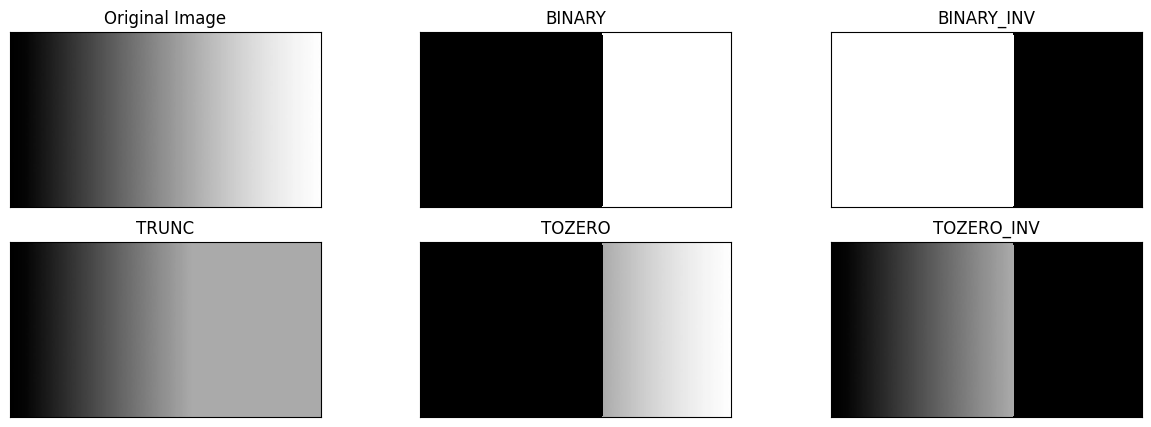

In [30]:
path = '/content/drive/MyDrive/asset/Images/gradient.jpg'

img = cv.imread(path)
thresh = 170 #nilai Threshold yang ditentukan

#1. thresh1 jika pixel di img>127, maka thresh1 bernilai 1(putih) selainitu bernilai 0(hitam)
ret,thresh1 = cv.threshold(img,thresh,255,cv.THRESH_BINARY)
#2. thresh2 adalah binary threshold inverse
ret,thresh2 = cv.threshold(img,thresh,255,cv.THRESH_BINARY_INV)
#3. Threshold Truncate
ret,thresh3 = cv.threshold(img,thresh,255,cv.THRESH_TRUNC)
#4. Threshold Tozero
ret,thresh4 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO)
#5. Threshold Tozero Inverse
ret,thresh5 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize = (15,5))
for i in range(len(images)):
  plt.subplot(2,3,i+1),plt.imshow(images[i],'gray', interpolation='nearest')
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])
plt.show()

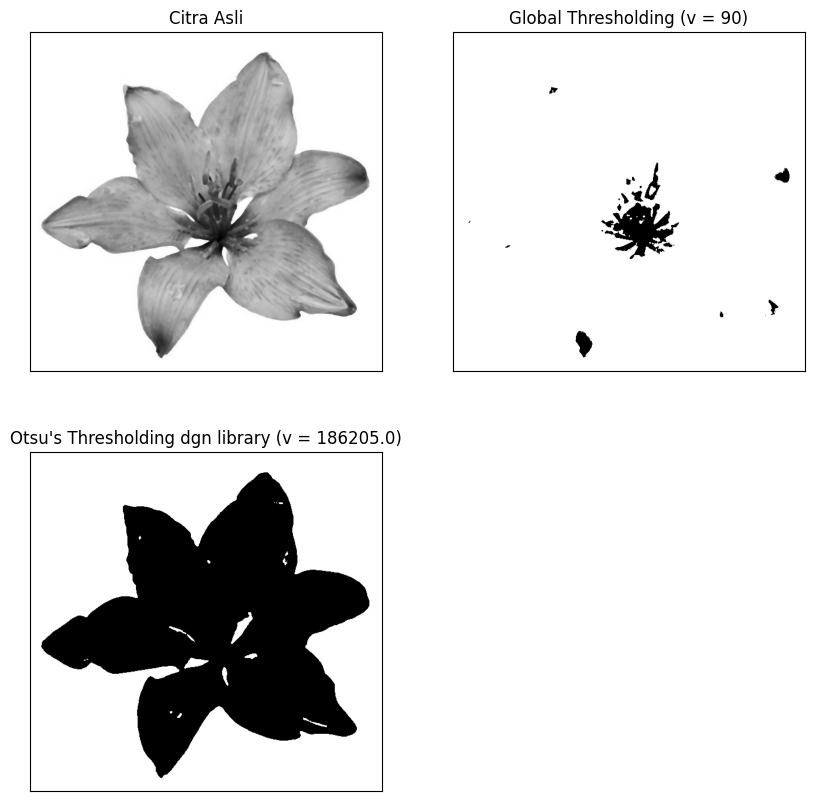

In [34]:
path = ('/content/drive/MyDrive/asset/Images/lily.jpg')
citra = cv.medianBlur(cv.imread(path),5)
gray = cv.cvtColor(citra, cv.COLOR_BGR2GRAY)
#gray = cv.medianBlur(gray,5)

thresh = 90

ret,th1 = cv.threshold(gray,thresh,255,cv.THRESH_BINARY)
ret2,th2 = cv.threshold(gray,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)

x = ("Otsu's Thresholding dgn library (v = 186")+str(ret2)+")"
titles = ['Citra Asli', 'Global Thresholding (v = 90)', x]
citra2 = [gray, th1, th2]

plt.figure(figsize = (10,10))
for i in range(len(citra2)):
  plt.subplot(2,2,i+1),plt.imshow(citra2[i],'gray')
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])
plt.show()

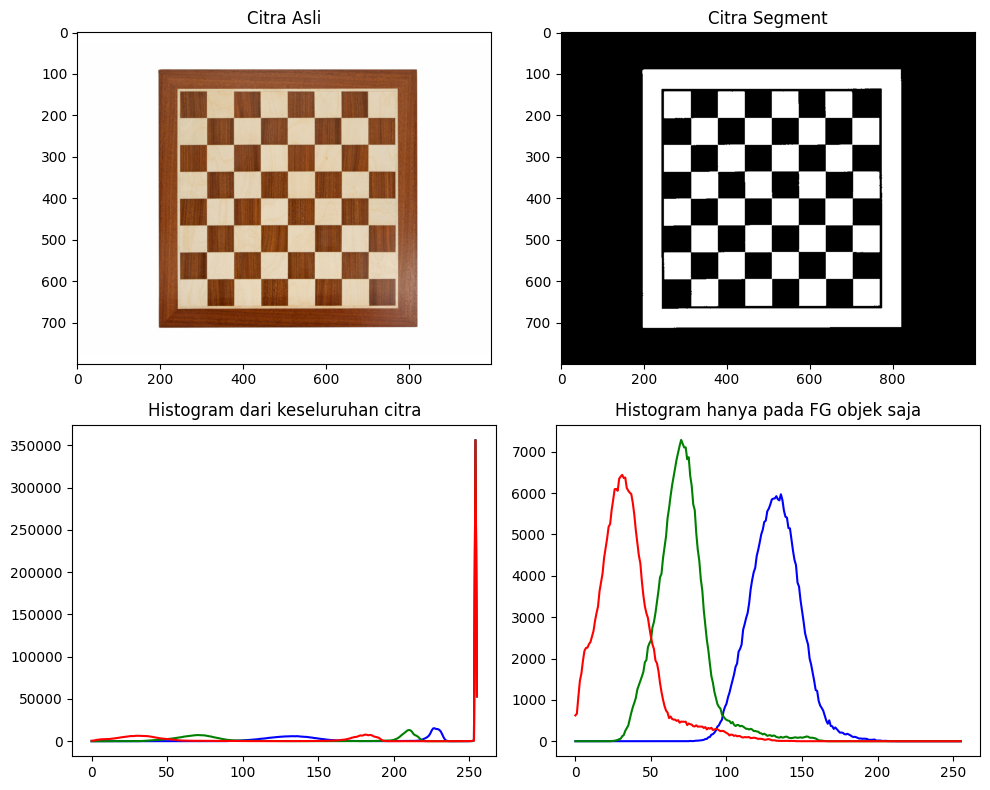

In [33]:
#KMeans Image Segmentation
filename = ('/content/drive/MyDrive/asset/Images/Object Detection/chess-board.jpg')
img = cv.imread(filename)
img = cv.cvtColor(img,cv.COLOR_BGR2RGB)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

_, mask = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
segment = cv.bitwise_and(img, img, mask=mask)

color = ('b', 'g', 'r')

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.imshow(img)
plt.title("Citra Asli")

plt.subplot(2,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Citra Segment")

plt.subplot(2,2,3)
for i, col in enumerate(color):
    hist = cv.calcHist([img],[i],None,[256],[0,256])
    plt.plot(hist, color=col)
plt.title("Histogram dari keseluruhan citra")

plt.subplot(2,2,4)
for i, col in enumerate(color):
    hist_fg = cv.calcHist([img],[i],mask,[256],[0,256])
    plt.plot(hist_fg, color=col)
plt.title("Histogram hanya pada FG objek saja")

plt.tight_layout()
plt.show()

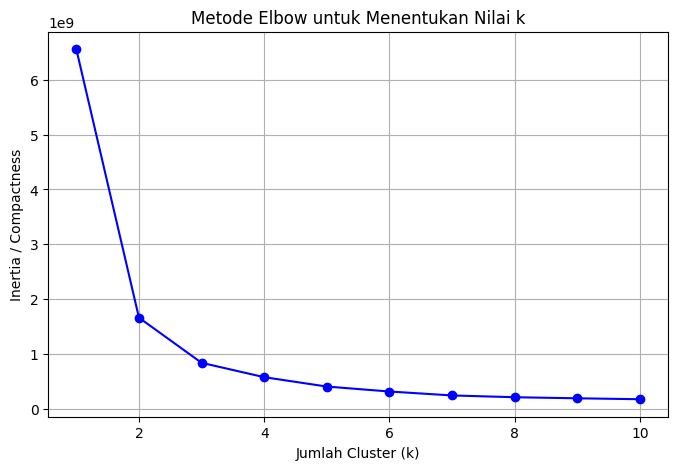

In [73]:
#KMeans Image Segmentation
filename = ('/content/drive/MyDrive/asset/Images/peppers.jpg')
img = cv.imread(filename)
img = cv.cvtColor(img,cv.COLOR_BGR2RGB)

#reshape array ke bentuk 2D
pixel_values = img.reshape((-1, 3))
# convert to float
pixel_values = np.float32(pixel_values)

criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)

inertias = []
K = range(1, 11)

for k in K:
    compactness, labels, centers = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
    inertias.append(compactness)

plt.figure(figsize=(8, 5))
plt.plot(K, inertias, 'bo-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia / Compactness')
plt.title('Metode Elbow untuk Menentukan Nilai k')
plt.grid(True)
plt.show()

(<Axes: >, <matplotlib.image.AxesImage at 0x7b5a89689ac0>)

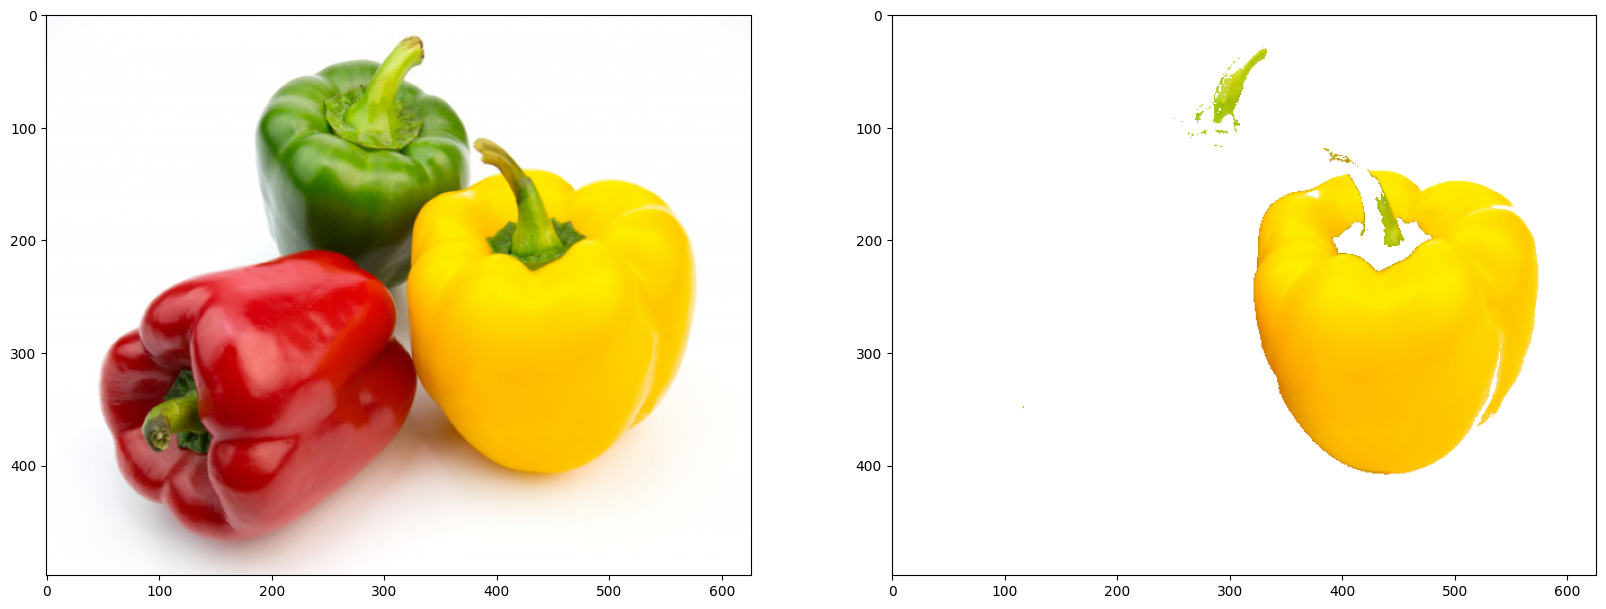

In [83]:
k = 5
_, labels, (centers) = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
#konversi titik centroid kedalam integer
centers = np.uint8(centers)
#flattening label array
labels = labels.flatten()
#konversi warna pixel asli kewarna dari tiap centroidnya
segmented_image = centers[labels.flatten()]

selected_cluster = 2

# buat mask: True di area dengan label == selected_cluster
mask = (labels == selected_cluster)
mask = mask.reshape(img.shape[:2])

# buat citra baru yang hanya menampilkan cluster itu
# selain cluster dipenuhi warna putih
isolated = np.ones_like(img) * 255
isolated[mask] = img[mask]

# reshape ke bentuk image asli
segmented_image = segmented_image.reshape(img.shape)
plt.figure(figsize = (20,20))
plt.subplot(1,2,1),plt.imshow(img)
plt.subplot(1,2,2),plt.imshow(isolated)

## Kendala yang Dihadapi

Percobaan pertama menggunakan nilai k=4 dengan asumsi 3 warna pepper akan muncul + 1 warna background. Hasil yang muncul justru 1 warna background, 2 warna pepper dan 1 warna background. Warna pepper yang muncul adalah warna kuning sehingga seharusnya sudah cukup untuk melakukan masking pada warna kuning saja meskipun terdapat sedikit bagian pada batang pepper hijau yang tersegmentasi ke warna kuning juga

Percobaan kedua mencoba menggunakan elbow method untuk mendeteksi nilai k yang paling optimal justru menunjukkan k=2. Citra hanya akan terbagi akan foreground dan background sehingga nilai k dari elbow method tidak bisa digunakan

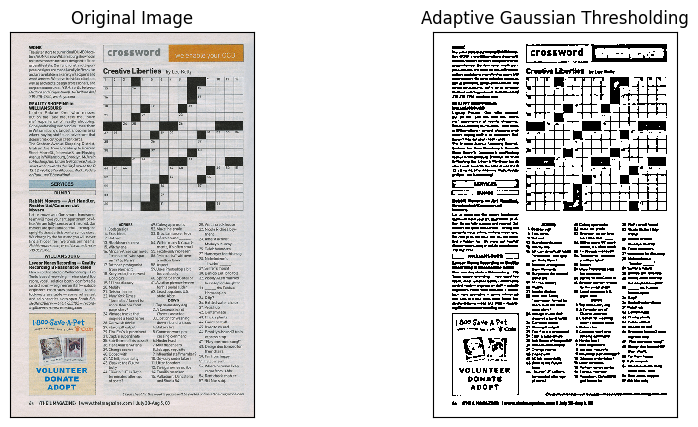

In [71]:
path = '/content/drive/MyDrive/asset/Images/crossword.jpg'

img = cv.imread(path)
img = cv.cvtColor(img,cv.COLOR_BGR2RGB)
blur = cv.GaussianBlur(img, (5,5), 0)
gray = cv.cvtColor(blur, cv.COLOR_BGR2GRAY)

thresh = cv.adaptiveThreshold(gray,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY,35, 11)

titles = ['Original Image','Adaptive Gaussian Thresholding']
images = [img, thresh]

plt.figure(figsize = (10,5))
for i in range(len(images)):
  plt.subplot(1,2,i+1),plt.imshow(images[i],'gray', interpolation='nearest')
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])
plt.show()

Penggunaan Adaptive Gaussian Thresholding dengan melakukan grayscaling dan blurring pada citra menunjukkan hasil terbaik.